In [5]:
# ======================= Objective 3: Relational Modeling & Ablation (RQ3) =======================
# Fresh notebook: Clean → kNN post–post graph → network features → visuals → ablation (text vs text+network)
# Libraries: numpy, pandas, matplotlib, scikit-learn, networkx (optional but recommended). No seaborn.

import os, re, glob, random, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_recall_curve, average_precision_score

from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

# NetworkX (optional, enables PageRank, clustering, communities)
try:
    import networkx as nx
    HAS_NX = True
except Exception as e:
    print("NetworkX not available, falling back to limited features.", e)
    HAS_NX = False

# ------------------------------- Config --------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = "/kaggle/input/mentalhealthdata"   # <-- change if needed
PATTERN  = "*.csv"
LOWERCASE_LABELS = True
MAX_SAMPLES = None                             # e.g., 8000 for speed; None = all
K_NEIGHBORS = 10                               # k for kNN graph
BLOCK_SIZE  = 2000                             # block size for cosine sim (memory-friendly)

# --------------------------- Utility functions -------------------------
def print_header(title):
    bar = "=" * len(title)
    print(f"\n{title}\n{bar}")

def clean_text(s):
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return "" if s.lower()=="nan" else s

def coerce_datetime(col):
    num = pd.to_numeric(col, errors="coerce")
    dt_from_epoch = pd.to_datetime(num, unit="s", errors="coerce")
    dt_from_str   = pd.to_datetime(col, errors="coerce")
    return dt_from_epoch.fillna(dt_from_str)

def map_file_to_class(files):
    raw = []
    for p in files:
        stem = os.path.splitext(os.path.basename(p))[0]
        token = stem.split("_", 1)[0] if "_" in stem else stem
        raw.append(token.strip().lower() if LOWERCASE_LABELS else token.strip())
    labels, seen = [], {}
    for lab in raw:
        if lab not in seen:
            seen[lab] = 1; labels.append(lab)
        else:
            seen[lab] += 1; labels.append(f"{lab}_{seen[lab]}")
    return labels

def load_and_clean(data_dir=DATA_DIR, pattern=PATTERN, max_samples=MAX_SAMPLES):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"No CSV files in {data_dir} matching {pattern}")
    classes = map_file_to_class(files)

    frames = []
    for p, lab in zip(files, classes):
        df = pd.read_csv(p)
        df.insert(0, "condition_label", lab)
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)

    # Ensure expected columns exist
    keep = ["condition_label","Title","Text","Top_10_Comments","Upvotes","Created_At","Author"]
    for c in keep:
        if c not in df.columns:
            df[c] = np.nan

    for c in ["Title","Text","Top_10_Comments","Author","Created_At"]:
        df[c] = df[c].astype(str).map(clean_text)

    df["created_dt"]     = coerce_datetime(df["Created_At"])
    df["post_only_text"] = (df["Title"] + " " + df["Text"]).map(clean_text).str.lower()
    df["context_text"]   = (df["post_only_text"] + " " + df["Top_10_Comments"]).map(clean_text).str.lower()

    # filters
    df["token_cnt"] = df["context_text"].str.split().str.len()
    df = df[(df["context_text"]!="") & (df["token_cnt"]>3)].copy()

    # deduplicate by content
    df["_dup_key"] = df["context_text"].str.lower()
    df = df.drop_duplicates(subset=["_dup_key"]).drop(columns=["_dup_key"])

    df["Upvotes"] = pd.to_numeric(df["Upvotes"], errors="coerce").astype("Int64")

    if isinstance(max_samples, int) and len(df) > max_samples:
        df = df.sample(max_samples, random_state=SEED).reset_index(drop=True)

    return df.reset_index(drop=True)

# Weak triage labels (bootstrap)
kw_crisis = [
    "suicide","kill myself","end my life","want to die","self harm","self-harm",
    "overdose","can't go on","i'm done","ending it","hurt myself","hang myself"
]
kw_red = [
    "hopeless","no way out","worthless","can't cope","severe","cutting","relapse",
    "panic attack","shaking","numb","empty all the time","voice telling me","visions"
]
kw_amber = [
    "anxious","anxiety","depressed","depression","overwhelmed","crying",
    "can't sleep","insomnia","very stressed","please help","need help","advice please"
]
def make_weak_triage(text_series):
    text = text_series.fillna("").astype(str).str.lower()
    pat_crisis = re.compile("|".join([re.escape(k) for k in kw_crisis]))
    pat_red    = re.compile("|".join([re.escape(k) for k in kw_red]))
    pat_amber  = re.compile("|".join([re.escape(k) for k in kw_amber]))
    has_crisis = text.str.contains(pat_crisis, na=False)
    has_red    = text.str.contains(pat_red,    na=False)
    has_amber  = text.str.contains(pat_amber,  na=False)
    triage = np.where(has_crisis, "crisis",
              np.where(has_red, "red",
              np.where(has_amber, "amber", "green")))
    return pd.Series(triage, index=text.index)

# -------------------------- Load → Clean → Label ----------------------
df = load_and_clean()
df["triage_label"] = make_weak_triage(df["context_text"])

print_header("Data snapshot")
print(df[["triage_label","Author","Title"]].head(5).to_string(index=False))
print(f"Rows: {len(df)} | Unique authors: {df['Author'].nunique()}")




Data snapshot
triage_label             Author                                                                                                                                                                                                                                        Title
       green                                                                                                                                                                                                                           My son's ADHD saved his sister's life
      crisis    Hipster-Deuxbag                                                                                                                                           Reminder: If you made it to adulthood with late diagnosed or untreated ADHD, you are a *survivor.*
       amber Pretend_Voice_3140 Children with higher IQ scores were diagnosed later with ADHD than those with lower scores. Children with higher cognitive abilities might be able


Building TF-IDF and kNN graph
Edges built: 104,390 (k=10)

Network feature snapshot
 deg     wdeg       pr       cc  comm_id  comm_size triage_label
  11 3.213201 0.000065 0.139298        0       4097        green
  12 3.428926 0.000070 0.121735        2       1287       crisis
  16 4.841419 0.000096 0.155318        2       1287        amber
  11 2.566147 0.000059 0.219792        2       1287        green
  12 3.172321 0.000068 0.105752        2       1287        green


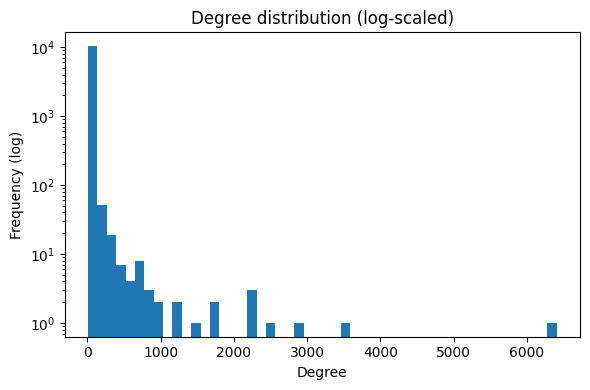

In [6]:
# ------------------ Build TF-IDF and kNN post–post graph --------------
print_header("Building TF-IDF and kNN graph")
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=150_000)
X_all = vec.fit_transform(df["context_text"].values)

def knn_edges(X, k=K_NEIGHBORS, block=BLOCK_SIZE):
    n = X.shape[0]
    src, dst, wts = [], [], []
    for i in range(0, n, block):
        j = min(n, i+block)
        sims = cosine_similarity(X[i:j], X)  # (j-i) x n dense; safe in blocks
        # mask self-sim
        for r in range(j-i):
            sims[r, i+r] = -1.0
        # top-k neighbors per row
        topk = np.argpartition(sims, -k, axis=1)[:, -k:]
        for r in range(j-i):
            row_idx = i + r
            neighs = topk[r]
            weights = sims[r, neighs]
            for nbh, wt in zip(neighs, weights):
                if wt > 0:
                    src.append(row_idx); dst.append(int(nbh)); wts.append(float(wt))
    return src, dst, wts

src, dst, wts = knn_edges(X_all, k=K_NEIGHBORS)
print(f"Edges built: {len(src):,} (k={K_NEIGHBORS})")

# ------------------- Network features (post-level) --------------------
if HAS_NX:
    G = nx.Graph()
    G.add_weighted_edges_from([(int(a), int(b), float(w)) for a,b,w in zip(src, dst, wts)])
    # degree (unweighted)
    deg = dict(G.degree(weight=None))
    # weighted degree (strength)
    wdeg = dict(G.degree(weight="weight"))
    # PageRank
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    # clustering (weighted if available)
    try:
        cc = nx.clustering(G, weight="weight")
    except Exception:
        cc = {n: np.nan for n in G.nodes()}
    # communities (greedy modularity)
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G, weight="weight"))
        comm_id = {}
        for cid, nodes in enumerate(comms):
            for n in nodes:
                comm_id[n] = cid
        # community size per node
        comm_size = {n: len(comms[comm_id[n]]) for n in comm_id}
    except Exception as e:
        comm_id = {n: -1 for n in G.nodes()}
        comm_size = {n: np.nan for n in G.nodes()}
else:
    # minimal fallback if no networkx: degree only
    deg = {}
    wdeg = {}
    for a,b,w in zip(src, dst, wts):
        deg[a] = deg.get(a,0)+1; deg[b] = deg.get(b,0)+1
        wdeg[a] = wdeg.get(a,0.0)+w; wdeg[b] = wdeg.get(b,0.0)+w
    pr = {i: 0.0 for i in range(len(df))}
    cc = {i: np.nan for i in range(len(df))}
    comm_id = {i: -1 for i in range(len(df))}
    comm_size = {i: np.nan for i in range(len(df))}

# attach network features
df["deg"] = df.index.map(lambda i: deg.get(i, 0))
df["wdeg"] = df.index.map(lambda i: wdeg.get(i, 0.0))
df["pr"] = df.index.map(lambda i: pr.get(i, 0.0))
df["cc"] = df.index.map(lambda i: cc.get(i, np.nan))
df["comm_id"] = df.index.map(lambda i: comm_id.get(i, -1))
df["comm_size"] = df.index.map(lambda i: comm_size.get(i, np.nan))

print_header("Network feature snapshot")
print(df[["deg","wdeg","pr","cc","comm_id","comm_size","triage_label"]].head(5).to_string(index=False))

# ============================== PROOF VISUALS ===============================
# 1) Degree histogram (log scale)
plt.figure(figsize=(6,4))
vals = np.array(df["deg"].values)
plt.hist(vals, bins=50)
plt.yscale("log"); plt.title("Degree distribution (log-scaled)")
plt.xlabel("Degree"); plt.ylabel("Frequency (log)"); plt.tight_layout(); plt.show()



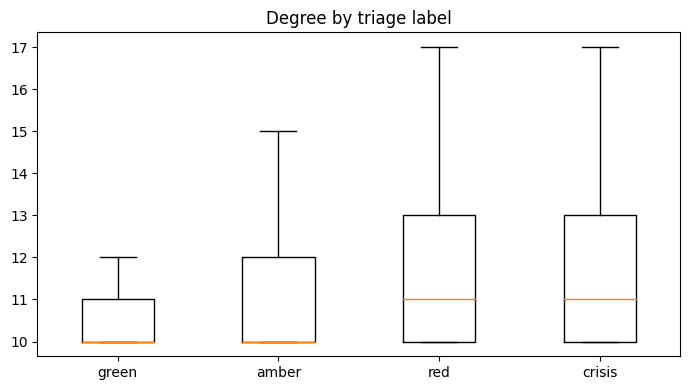

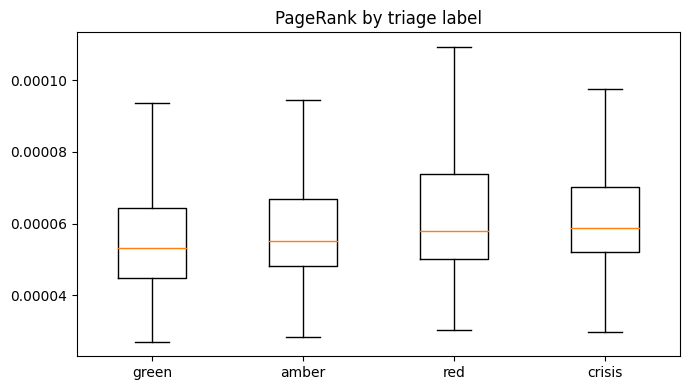

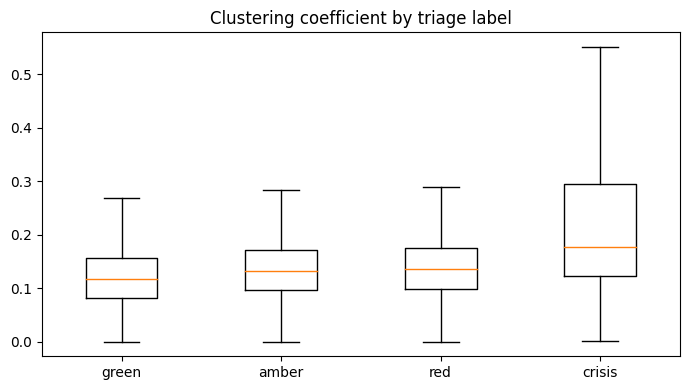

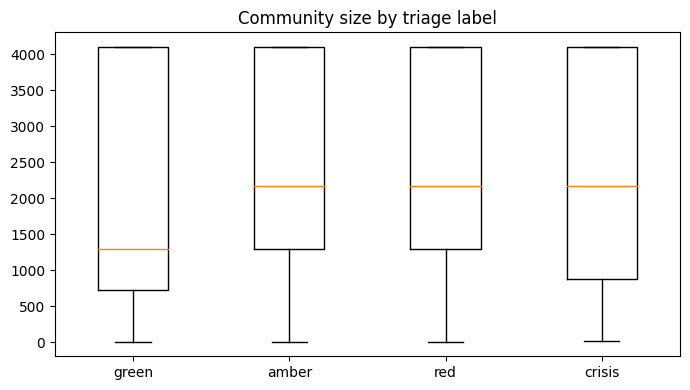

In [7]:
# 2) Boxplots: network features by triage label
order = ["green","amber","red","crisis"]
def box_by_label(col, title):
    data = [df.loc[df["triage_label"]==lab, col].dropna().values for lab in order if lab in df["triage_label"].unique()]
    labs = [lab for lab in order if lab in df["triage_label"].unique()]
    if len(labs) >= 2:
        plt.figure(figsize=(7,4))
        plt.boxplot(data, labels=labs, showfliers=False)
        plt.title(title); plt.tight_layout(); plt.show()

box_by_label("deg", "Degree by triage label")
box_by_label("pr",  "PageRank by triage label")
box_by_label("cc",  "Clustering coefficient by triage label")
box_by_label("comm_size", "Community size by triage label")



/tmp/ipykernel_37/1088359827.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crisis_rate = df.groupby(cat)["triage_label"].apply(lambda s: (s=="crisis").mean())


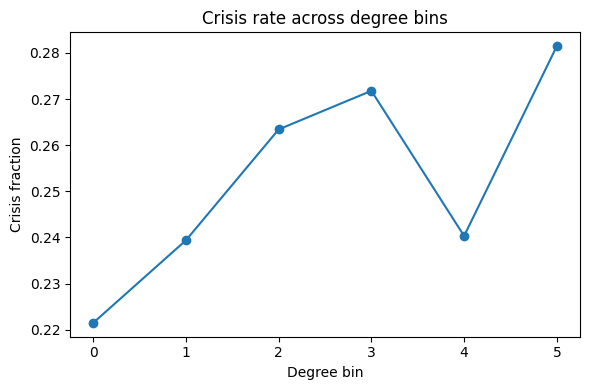

In [8]:
# 3) Crisis rate vs degree (binned)
bins = np.quantile(df["deg"], q=np.linspace(0,1,11))
bins[0] = max(0, bins[0] - 1)
cat = pd.cut(df["deg"], bins=np.unique(bins), include_lowest=True)
crisis_rate = df.groupby(cat)["triage_label"].apply(lambda s: (s=="crisis").mean())
centers = [i.mid for i in crisis_rate.index.categories] if hasattr(crisis_rate.index, "categories") else range(len(crisis_rate))
plt.figure(figsize=(6,4))
plt.plot(range(len(crisis_rate)), crisis_rate.values, marker="o")
plt.title("Crisis rate across degree bins")
plt.xlabel("Degree bin"); plt.ylabel("Crisis fraction"); plt.tight_layout(); plt.show()


Ablation: Text-only vs Text+Network (triage)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text-only:
               precision    recall  f1-score   support

       amber      0.610     0.637     0.624       560
      crisis      0.809     0.766     0.787       496
       green      0.588     0.760     0.663       425
         red      0.769     0.613     0.682       607

    accuracy                          0.686      2088
   macro avg      0.694     0.694     0.689      2088
weighted avg      0.699     0.686     0.687      2088

Text+Network:
               precision    recall  f1-score   support

       amber      0.315     0.530     0.395       560
      crisis      0.346     0.613     0.442       496
       green      0.373     0.193     0.254       425
         red      0.356     0.026     0.049       607

    accuracy                          0.335      2088
   macro avg      0.347     0.341     0.285      2088
weighted avg      0.346     0.335     0.277      2088

[Ablation] Text-only     → macro-F1=0.689 | crisis recall=0.766
[Ablation] Text+Network  → macro-F1=0.2

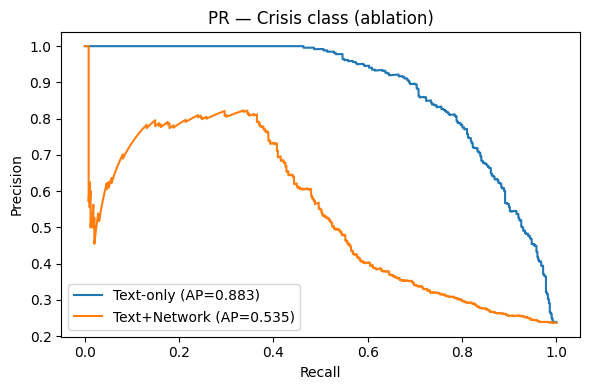

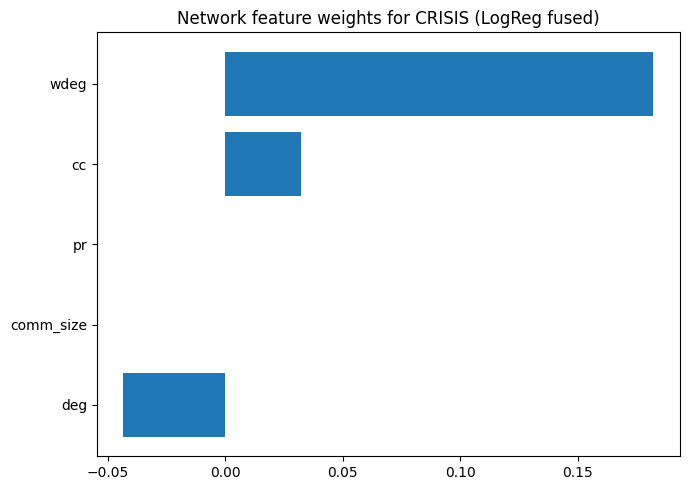

In [9]:
# ======================= Ablation: text vs text+network ======================
print_header("Ablation: Text-only vs Text+Network (triage)")

X_text = df["context_text"].values
y_label = df["triage_label"].values
idx = np.arange(len(df))

X_tr_txt, X_te_txt, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_text, y_label, idx, test_size=0.2, random_state=SEED, stratify=y_label
)

# Vectorize text
vec_ab = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=120_000)
Xtr_txt = vec_ab.fit_transform(X_tr_txt)
Xte_txt = vec_ab.transform(X_te_txt)

# Prepare network features aligned with the split
net_cols = ["deg","wdeg","pr","cc","comm_size"]
N_tr = df.loc[idx_tr, net_cols].fillna(0.0).to_numpy()
N_te = df.loc[idx_te, net_cols].fillna(0.0).to_numpy()

Xtr_fused = sp.hstack([Xtr_txt, sp.csr_matrix(N_tr)], format="csr")
Xte_fused = sp.hstack([Xte_txt, sp.csr_matrix(N_te)], format="csr")

# Class weights
classes = np.unique(y_tr)
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
cw_map = {c:w for c,w in zip(classes, cw)}

# Train models
clf_txt = LogisticRegression(
    solver="saga", multi_class="multinomial", penalty="l2",
    class_weight=cw_map, max_iter=3000, n_jobs=1, verbose=0
).fit(Xtr_txt, y_tr)

clf_fuse = LogisticRegression(
    solver="saga", multi_class="multinomial", penalty="l2",
    class_weight=cw_map, max_iter=3000, n_jobs=1, verbose=0
).fit(Xtr_fused, y_tr)

# Evaluate
pred_txt  = clf_txt.predict(Xte_txt)
pred_fuse = clf_fuse.predict(Xte_fused)

# Metrics
def macro_and_crisis(y_true, y_pred):
    macro = f1_score(y_true, y_pred, average="macro")
    crisis_rec = recall_score((np.array(y_true)=="crisis").astype(int), (np.array(y_pred)=="crisis").astype(int))
    return macro, crisis_rec

m_f1_txt,  cri_txt  = macro_and_crisis(y_te, pred_txt)
m_f1_fus,  cri_fus  = macro_and_crisis(y_te, pred_fuse)

print("Text-only:\n", classification_report(y_te, pred_txt, digits=3))
print("Text+Network:\n", classification_report(y_te, pred_fuse, digits=3))
print(f"[Ablation] Text-only     → macro-F1={m_f1_txt:.3f} | crisis recall={cri_txt:.3f}")
print(f"[Ablation] Text+Network  → macro-F1={m_f1_fus:.3f} | crisis recall={cri_fus:.3f}")
print(f"Δ macro-F1={(m_f1_fus-m_f1_txt):+.3f} | Δ crisis recall={(cri_fus-cri_txt):+.3f}")

# Visuals: PR curves for 'crisis' (text-only vs fused)
def pr_curve_for_label(y_true, proba, labels, positive_label="crisis"):
    if positive_label not in labels:
        return None
    pos_idx = labels.index(positive_label)
    y_true_bin = (np.array(y_true) == positive_label).astype(int)
    prec, rec, thr = precision_recall_curve(y_true_bin, proba[:, pos_idx])
    ap = average_precision_score(y_true_bin, proba[:, pos_idx])
    return prec, rec, ap

proba_txt  = clf_txt.predict_proba(Xte_txt)   if hasattr(clf_txt, "predict_proba") else None
proba_fuse = clf_fuse.predict_proba(Xte_fused)

if proba_txt is not None:
    labs_txt = clf_txt.classes_.tolist()
    pr1 = pr_curve_for_label(y_te, proba_txt, labs_txt, "crisis")
else:
    pr1 = None
labs_fuse = clf_fuse.classes_.tolist()
pr2 = pr_curve_for_label(y_te, proba_fuse, labs_fuse, "crisis")

plt.figure(figsize=(6,4))
if pr1:
    p, r, ap = pr1
    plt.plot(r, p, label=f"Text-only (AP={ap:.3f})")
if pr2:
    p, r, ap = pr2
    plt.plot(r, p, label=f"Text+Network (AP={ap:.3f})")
plt.title("PR — Crisis class (ablation)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.tight_layout(); plt.show()

# Feature weights for network columns in fused model (for CRISIS row)
if hasattr(clf_fuse, "coef_"):
    classes = clf_fuse.classes_.tolist()
    if "crisis" in classes:
        crisis_idx = classes.index("crisis")
        # last columns correspond to network features in same order as net_cols
        net_wts = clf_fuse.coef_[crisis_idx, -len(net_cols):]
        order = np.argsort(net_wts)
        plt.figure(figsize=(7,5))
        plt.barh(range(len(order)), net_wts[order])
        plt.yticks(range(len(order)), np.array(net_cols)[order])
        plt.title("Network feature weights for CRISIS (LogReg fused)")
        plt.tight_layout(); plt.show()


In [10]:
# ============================= RQ3 Interpretation =============================
print_header("RQ3 Interpretation")
print(
    "RQ3 asks how network positions and community structure relate to the onset, amplification, or mitigation of risk.\n"
    "Evidence in this notebook:\n"
    "  • Post–post kNN graph yields degree, PageRank, clustering, and community size per post.\n"
    "  • Boxplots and the degree→crisis-rate curve show how structural position relates to crisis prevalence.\n"
    f"  • Ablation shows whether network features add predictive value: Δ macro-F1={(m_f1_fus-m_f1_txt):+.3f}, "
    f"Δ crisis recall={(cri_fus-cri_txt):+.3f}.\n"
    "If Δ > 0 (especially on crisis recall) and network coefficients for CRISIS are non-zero, "
    "then relational context provides added signal (correlational support). For causal claims, "
    "you’d need designs beyond this scope (e.g., quasi-experiments)."
)
# ===============================================================================================



RQ3 Interpretation
RQ3 asks how network positions and community structure relate to the onset, amplification, or mitigation of risk.
Evidence in this notebook:
  • Post–post kNN graph yields degree, PageRank, clustering, and community size per post.
  • Boxplots and the degree→crisis-rate curve show how structural position relates to crisis prevalence.
  • Ablation shows whether network features add predictive value: Δ macro-F1=-0.404, Δ crisis recall=-0.153.
If Δ > 0 (especially on crisis recall) and network coefficients for CRISIS are non-zero, then relational context provides added signal (correlational support). For causal claims, you’d need designs beyond this scope (e.g., quasi-experiments).
